# 01. Исследовательский анализ данных (EDA)

Кредитный скоринг: знакомство с признаками заёмщиков для **Казахстана** и **России**.

В ноутбуке: описательная статистика, пропуски, распределения, корреляции и первые выводы для главы диплома.

In [1]:
# Пути: если запускаете из папки notebooks/, поднимаемся на уровень вверх
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import utils  # noqa: E402

utils.ensure_directories()
kz_path, ru_path = utils.ensure_raw_datasets_exist()
print("KZ:", kz_path)
print("RU:", ru_path)

KZ: /Users/dmitryapareev/Desktop/Диплом/вкр/code/credit_scoring_diploma/data/raw/kazakhstan_credit.csv
RU: /Users/dmitryapareev/Desktop/Диплом/вкр/code/credit_scoring_diploma/data/raw/russia_credit.csv


In [2]:
df_kz = pd.read_csv(kz_path, encoding="utf-8")
df_ru = pd.read_csv(ru_path, encoding="utf-8")

df_kz["country"] = "KZ"
df_ru["country"] = "RU"

print("Размер KZ:", df_kz.shape)
print("Размер RU:", df_ru.shape)
display(df_kz.head())

Размер KZ: (30000, 17)
Размер RU: (30000, 17)


,age,gender,region,monthly_income,employment_status,work_experience,loan_amount,loan_term,interest_rate,current_debt,debt_to_income,number_of_loans,overdue_count,max_days_overdue,loan_purpose,target,country
0,36,M,Zhambyl,79343.46,retired,9,223254.35,31,23.32,26821.39,0.3380,0,2,0,consumer,0,KZ
1,43,M,Turkistan,81941.59,student,21,759624.34,72,25.08,208413.38,2.5434,4,0,2,consumer,0,KZ
2,36,F,Aktobe,1206169.16,employed,12,4993505.94,28,44.21,3704833.73,3.0716,0,1,0,consumer,0,KZ
3,55,M,Almaty,218453.28,employed,30,2611631.10,64,16.14,1166345.14,5.3391,1,0,0,consumer,0,KZ
4,38,F,Shymkent,354217.98,employed,12,1917810.91,29,14.79,944532.94,2.6665,0,0,0,consumer,0,KZ


### Описание признаков

| Признак | Смысл |
|--------|--------|
| `age` | возраст заёмщика |
| `gender` | пол (M/F) |
| `region` | регион проживания |
| `monthly_income` | ежемесячный доход |
| `employment_status` | занятость (наём, ИП, безработный и т.д.) |
| `work_experience` | стаж (лет) |
| `loan_amount` | сумма кредита |
| `loan_term` | срок в месяцах |
| `interest_rate` | процентная ставка, % годовых |
| `current_debt` | текущая долговая нагрузка |
| `debt_to_income` | отношение долга к доходу |
| `number_of_loans` | число действующих кредитов |
| `overdue_count` | число случаев просрочки |
| `max_days_overdue` | макс. длительность просрочки (дней) |
| `loan_purpose` | цель кредита |
| `target` | **1** — дефолт, **0** — нет |

In [3]:
for name, df in [("Казахстан", df_kz), ("Россия", df_ru)]:
    print(f"\n=== {name} ===")
    print(df.describe(include="all").T.head(20))
    print("Пропуски:\n", df.isna().sum()[df.isna().sum() > 0])


=== Казахстан ===
                     count unique       top   freq            mean  \
age                30000.0    NaN       NaN    NaN       38.574867   
gender               30000      2         M  15026             NaN   
region               30000     17    Almaty   4784             NaN   
monthly_income     30000.0    NaN       NaN    NaN   261692.363367   
employment_status    30000      5  employed  19252             NaN   
work_experience    30000.0    NaN       NaN    NaN         14.5037   
loan_amount        30000.0    NaN       NaN    NaN  1809984.038924   
loan_term          30000.0    NaN       NaN    NaN       42.125967   
interest_rate      30000.0    NaN       NaN    NaN       24.028365   
current_debt       30000.0    NaN       NaN    NaN  1012697.783285   
debt_to_income     30000.0    NaN       NaN    NaN        3.834185   
number_of_loans    30000.0    NaN       NaN    NaN        1.523733   
overdue_count      30000.0    NaN       NaN    NaN        1.239033   
m

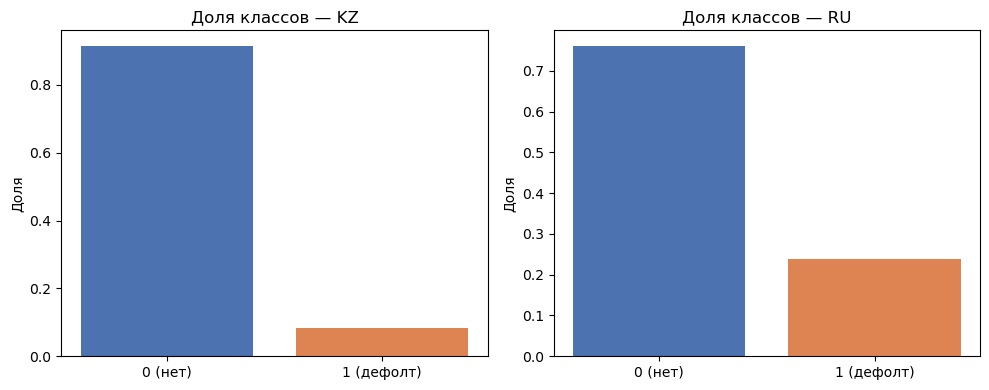

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, df) in zip(axes, [("KZ", df_kz), ("RU", df_ru)]):
    vc = df["target"].value_counts(normalize=True).sort_index()
    ax.bar(["0 (нет)", "1 (дефолт)"], vc.values, color=["#4c72b0", "#dd8452"])
    ax.set_title(f"Доля классов — {title}")
    ax.set_ylabel("Доля")
plt.tight_layout()
plt.show()

/Users/dmitryapareev/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/dmitryapareev/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/dmitryapareev/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/dmitryapareev/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be rem

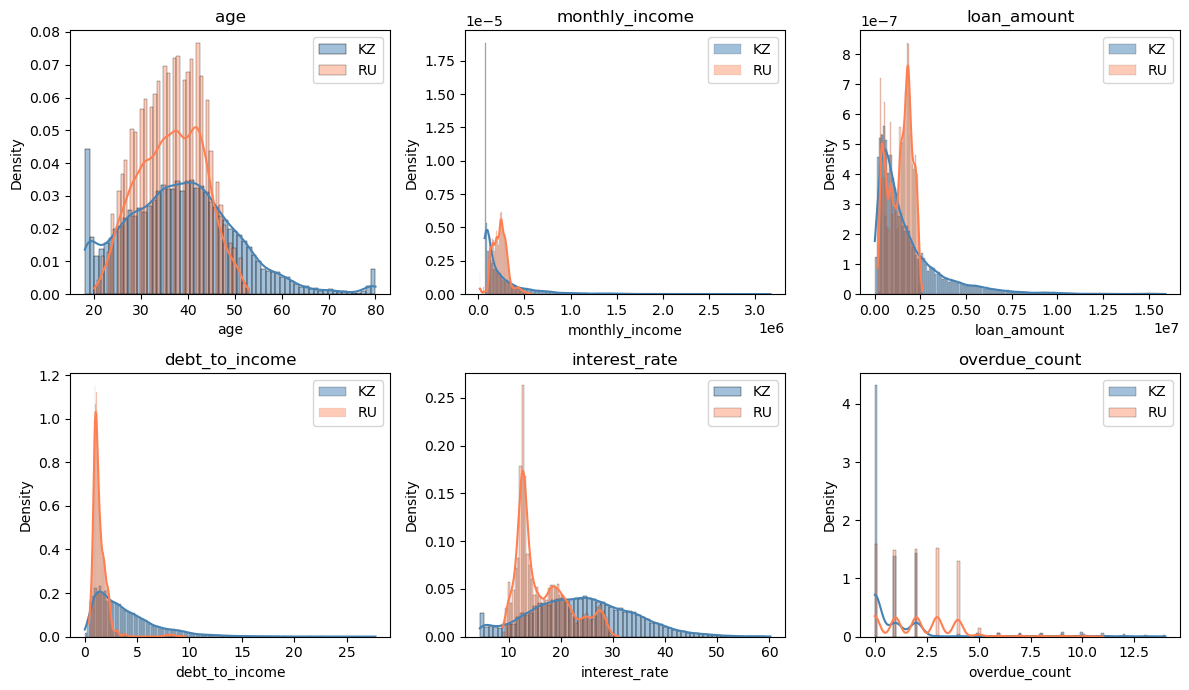

In [5]:
num_cols = [
    "age",
    "monthly_income",
    "loan_amount",
    "debt_to_income",
    "interest_rate",
    "overdue_count",
]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df_kz[col], kde=True, ax=axes[i], color="steelblue", label="KZ", stat="density")
    sns.histplot(df_ru[col], kde=True, ax=axes[i], color="coral", label="RU", stat="density", alpha=0.4)
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

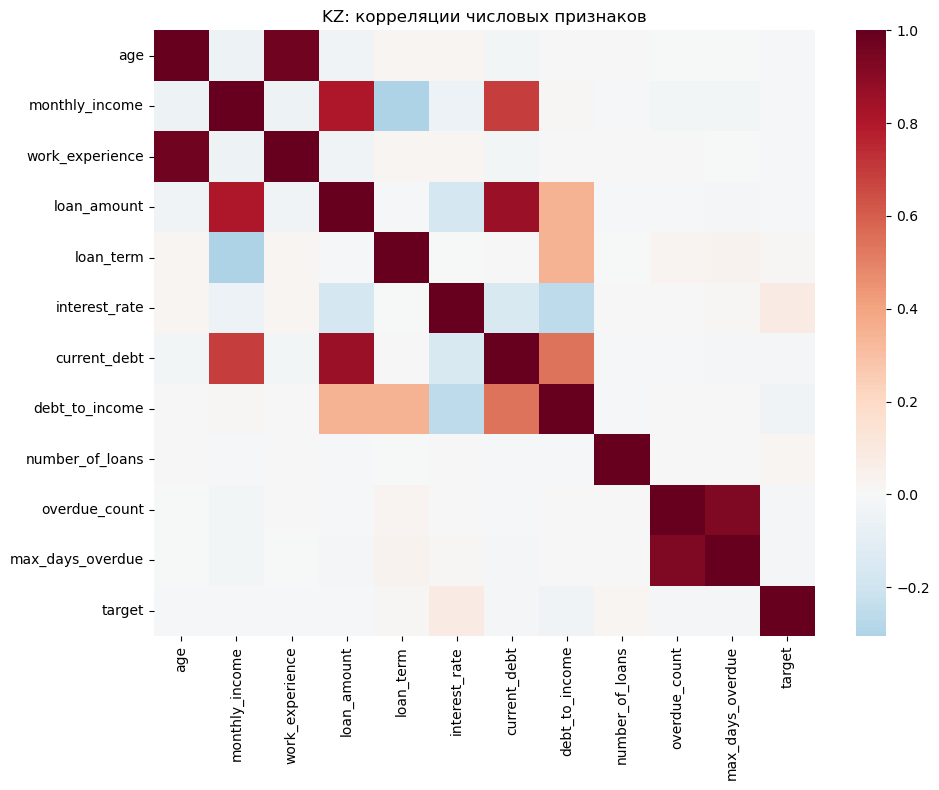

In [6]:
# корреляции 
plt.figure(figsize=(10, 8))
sns.heatmap(df_kz.select_dtypes(include=[np.number]).corr(), cmap="RdBu_r", center=0)
plt.title("KZ: корреляции числовых признаков")
plt.tight_layout()
plt.show()

Краткие выводы для главы 1–2: классы несбалансированы (70/30), доходы и суммы кредита по странам отличаются по масштабу (валюта/рынок), при этом структура признаков совпадает - это удобно для сравнения моделей.